<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula07a_m%C3%A9tricas_de_classifica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)
print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [2]:
import numpy as np

unique_labels, counts = np.unique(y, return_counts=True)
print(unique_labels)
print(counts)

[0 1 2]
[59 71 48]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X_train.shape)

(142, 13)


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.82      0.69      0.75        13
           1       0.55      0.55      0.55        11
           2       0.43      0.50      0.46        12

    accuracy                           0.58        36
   macro avg       0.60      0.58      0.59        36
weighted avg       0.60      0.58      0.59        36

[[9 0 4]
 [1 6 4]
 [1 5 6]]


In [19]:
precision_lablel0 = cm[0, 0] / cm[:,0].sum()
print(f"precision for label 0: {precision_lablel0:.2f}")
precision_lablel1 = cm[1, 1] / cm[:,1].sum()
print(f"precision for label 1: {precision_lablel1:.2f}")
precision_lablel2 = cm[2, 2] / cm[:,2].sum()
print(f"precision for label 2: {precision_lablel2:.2f}")
macro_precision = (precision_lablel0 + precision_lablel1 + precision_lablel2) / 3
print(f"macro precision: {macro_precision:.2f}")
weighted_precision = (precision_lablel0 * counts[0] + precision_lablel1 * counts[1] + precision_lablel2 * counts[2]) / y.shape[0]
print(f"weighted precision: {weighted_precision:.2f}")

precision for label 0: 0.82
precision for label 1: 0.55
precision for label 2: 0.43
macro precision: 0.60
weighted precision: 0.60


In [20]:
recall_lablel0 = cm[0, 0] / cm[0,:].sum()
print(f"recall for label 0: {recall_lablel0:.2f}")
recall_lablel1 = cm[1, 1] / cm[1,:].sum()
print(f"recall for label 1: {recall_lablel1:.2f}")
recall_lablel2 = cm[2, 2] / cm[2,:].sum()
print(f"recall for label 2: {recall_lablel2:.2f}")
macro_recall = (recall_lablel0 + recall_lablel1 + recall_lablel2) / 3
print(f"macro recall: {macro_recall:.2f}")
weighted_recall = (recall_lablel0 * counts[0] + recall_lablel1 * counts[1] + recall_lablel2 * counts[2]) / y.shape[0]
print(f"weighted recall: {weighted_recall:.2f}")

recall for label 0: 0.69
recall for label 1: 0.55
recall for label 2: 0.50
macro recall: 0.58
weighted recall: 0.58


In [22]:
f1_label0 = 2 * precision_lablel0 * recall_lablel0 / (precision_lablel0 + recall_lablel0)
print(f"f1 score for label 0: {f1_label0:.2f}")
f1_label1 = 2 * precision_lablel1 * recall_lablel1 / (precision_lablel1 + recall_lablel1)
print(f"f1 score for label 1: {f1_label1:.2f}")
f1_label2 = 2 * precision_lablel2 * recall_lablel2 / (precision_lablel2 + recall_lablel2)
print(f"f1 score for label 2: {f1_label2:.2f}")
macro_f1 = (f1_label0 + f1_label1 + f1_label2) / 3
print(f"macro f1 score: {macro_f1:.2f}")
weighted_f1 = (f1_label0 * counts[0] + f1_label1 * counts[1] + f1_label2 * counts[2]) / y.shape[0]
print(f"weighted f1 score: {weighted_f1:.2}")

f1 score for label 0: 0.75
f1 score for label 1: 0.55
f1 score for label 2: 0.46
macro f1 score: 0.59
weighted f1 score: 0.59


In [24]:
accuracy = (cm[0,0] + cm[1,1] + cm[2,2]) / cm.sum()
print(f"accuracy: {accuracy:.2f}")

accuracy: 0.58


# Falha em conseguir recall alto

In [25]:
positivos = 10
negativos = 990
porcentagem_positivos = positivos / (positivos + negativos)
print(f"porcentagem de positivos: {porcentagem_positivos:.2f}")
porcentagem_negativos = negativos / (positivos + negativos)
print(f"porcentagem de negativos: {porcentagem_negativos:.2f}")

porcentagem de positivos: 0.01
porcentagem de negativos: 0.99


In [33]:
import numpy as np

cm = np.array([[1,   9],
               [0, 990]])
def estimate_metrics(cm):
  accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
  print(f"accuracy: {accuracy:.2f}")
  precision = cm[0,0] / cm[:,0].sum()
  print(f"precision: {precision:.2f}")
  recall = cm[0,0] / cm[0,:].sum()
  print(f"recall: {recall:.2f}")
estimate_metrics(cm)

accuracy: 0.99
precision: 1.00
recall: 0.10


# Conseguindo Recall alto

In [34]:
cm = np.array([
    [10, 0],
    [90, 900]
])
estimate_metrics(cm)

accuracy: 0.91
precision: 0.10
recall: 1.00


# Conseguindo precisão alta às custas de recall baixo

In [35]:
positivos = 100
negativos = 900

cm = np.array([
    [1,  99],
    [0, 900]
])
estimate_metrics(cm)

accuracy: 0.90
precision: 1.00
recall: 0.01


# Outras métricas


In [39]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X_train.shape)

(455, 30)


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test, y_pred_proba))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print(fpr)
print(tpr)
print(thresholds)

0.989059829059829
[0.         0.         0.         0.02564103 0.02564103 0.05128205
 0.05128205 0.1025641  0.1025641  0.23076923 0.23076923 1.        ]
[0.         0.01333333 0.86666667 0.86666667 0.90666667 0.90666667
 0.93333333 0.93333333 0.98666667 0.98666667 1.         1.        ]
[           inf 9.99999837e-01 8.56940470e-01 8.28016634e-01
 7.70314970e-01 7.65096030e-01 6.69842203e-01 4.65640513e-01
 3.93027672e-01 1.92677608e-01 1.85969263e-01 1.44655056e-40]


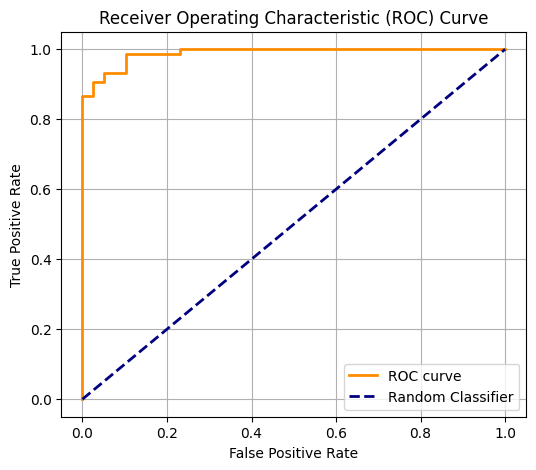

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [53]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

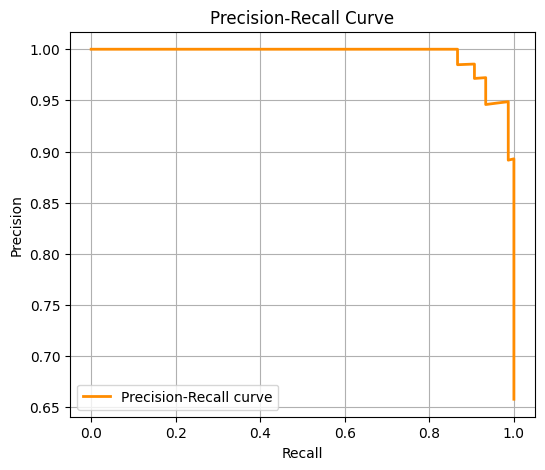

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='darkorange', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()